### Step 1 - Data Loading ###
*   In this section we will take the downloaded data files from the Austin Animal Center and upload the csv files to our workspace. We will also import the necessary extensions and do verification checks.

In [78]:
import pandas as pd

#define base path
base_path = r"C:\Users\hstuken\OneDrive - Western Governors University\Capstone project\Capstone Data"

#Load Intake Files
intakes = pd.read_csv(base_path + r"\Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260325.csv")

#Load Outcome Files
outcomes = pd.read_csv(base_path + r"\Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260325.csv")


In [79]:
#Verify the dataframes
print(intakes.head())
print(outcomes.head())  

  Animal ID    Name                DateTime     MonthYear  \
0   A521520    Nina  10/01/2013 07:51:00 AM  October 2013   
1   A664235     NaN  10/01/2013 08:33:00 AM  October 2013   
2   A664236     NaN  10/01/2013 08:33:00 AM  October 2013   
3   A664237     NaN  10/01/2013 08:33:00 AM  October 2013   
4   A664233  Stevie  10/01/2013 08:53:00 AM  October 2013   

                   Found Location Intake Type Intake Condition Animal Type  \
0         Norht Ec in Austin (TX)       Stray           Normal         Dog   
1             Abia in Austin (TX)       Stray           Normal         Cat   
2             Abia in Austin (TX)       Stray           Normal         Cat   
3             Abia in Austin (TX)       Stray           Normal         Cat   
4  7405 Springtime in Austin (TX)       Stray          Injured         Dog   

  Sex upon Intake Age upon Intake                         Breed         Color  
0   Spayed Female         7 years  Border Terrier/Border Collie     White/Tan  
1   

In [80]:
#Checking the column names of the two four datasset to ensure they are the same before merging
print(f"Intake Column Names: {intakes.columns.tolist()}")
print(f"Outcomes Column Names: {outcomes.columns.tolist()}")

Intake Column Names: ['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color']
Outcomes Column Names: ['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']


### Step 2 - Data Filtering ###
*   In this section we will be filtering the dataset to include only dogs and cats. Then we will join the intakes and outcomes on Animal ID.

In [81]:
#filter to dogs and cats only
intakes_dc = intakes[intakes['Animal Type'].isin(['Dog', 'Cat'])]
outcomes_dc = outcomes[outcomes['Animal Type'].isin(['Dog', 'Cat'])]        

print(f"Intakes: {intakes_dc.shape[0]}")
print(f"Outcomes: {outcomes_dc.shape[0]}")
print(f"Intakes by type:", intakes_dc['Animal Type'].value_counts().to_dict())
print(f"Outcomes by type:", outcomes_dc['Animal Type'].value_counts().to_dict())


Intakes: 163932
Outcomes: 163904
Intakes by type: {'Dog': 94608, 'Cat': 69324}
Outcomes by type: {'Dog': 94505, 'Cat': 69399}


In [82]:
#join intakes and outcomes on animal_id
df = pd.merge(intakes_dc, outcomes_dc, on='Animal ID',how='inner')

print(f"Joined DataFrame shape: {df.shape}")
print(df.head())   
print(df.columns.tolist())

Joined DataFrame shape: (211295, 23)
  Animal ID  Name_x              DateTime_x   MonthYear_x  \
0   A521520    Nina  10/01/2013 07:51:00 AM  October 2013   
1   A664235     NaN  10/01/2013 08:33:00 AM  October 2013   
2   A664236     NaN  10/01/2013 08:33:00 AM  October 2013   
3   A664237     NaN  10/01/2013 08:33:00 AM  October 2013   
4   A664233  Stevie  10/01/2013 08:53:00 AM  October 2013   

                   Found Location Intake Type Intake Condition Animal Type_x  \
0         Norht Ec in Austin (TX)       Stray           Normal           Dog   
1             Abia in Austin (TX)       Stray           Normal           Cat   
2             Abia in Austin (TX)       Stray           Normal           Cat   
3             Abia in Austin (TX)       Stray           Normal           Cat   
4  7405 Springtime in Austin (TX)       Stray          Injured           Dog   

  Sex upon Intake Age upon Intake  ...  Name_y           DateTime_y  \
0   Spayed Female         7 years  ...    Ni

### Step 3 - Data Cleaning ###
*   Here we are dropping unnecessary colums, handling missing values, and converting data types.

In [83]:
#drop duplicate columns and rename columns to avoid confusion
df = df.drop(columns=['Name_y', 'MonthYear_y', 'Animal Type_y', 'Breed_y', 'Color_y']) 
df = df.rename(columns={
    'Name_x': 'Name',
    'DateTime_x': 'Intake DateTime',
    'MonthYear_x': 'Intake MonthYear',
    'Animal Type_x': 'Animal Type',
    'Breed_x': 'Breed',
    'Color_x': 'Color',
    'DateTime_y': 'Outcome DateTime',
})

print("Cleaned columns:", df.columns.tolist())
print("Shape:", df.shape)

Cleaned columns: ['Animal ID', 'Name', 'Intake DateTime', 'Intake MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color', 'Date of Birth', 'Outcome DateTime', 'Outcome Type', 'Outcome Subtype', 'Sex upon Outcome', 'Age upon Outcome']
Shape: (211295, 18)


In [84]:
#Checking data types 
print(df.dtypes)

Animal ID           str
Name                str
Intake DateTime     str
Intake MonthYear    str
Found Location      str
Intake Type         str
Intake Condition    str
Animal Type         str
Sex upon Intake     str
Age upon Intake     str
Breed               str
Color               str
Date of Birth       str
Outcome DateTime    str
Outcome Type        str
Outcome Subtype     str
Sex upon Outcome    str
Age upon Outcome    str
dtype: object


In [87]:
#convert data columns to datetime
df['Intake DateTime'] = pd.to_datetime(df['Intake DateTime'])
df["Intake MonthYear"] = pd.to_datetime(df["Intake MonthYear"], format="%B %Y")

#convert outcome datetime to datetime using ISO8601 format
df['Outcome DateTime'] = pd.to_datetime(df['Outcome DateTime'], format='ISO8601', utc=True)

#remove timezone information to match intake datetime
df['Outcome DateTime'] = df['Outcome DateTime'].dt.tz_localize(None)


In [88]:
#Verify the conversions
print(df.dtypes)
print(df["Intake MonthYear"].head())
print(df["Intake DateTime"].head())

Animal ID                      str
Name                           str
Intake DateTime     datetime64[us]
Intake MonthYear    datetime64[us]
Found Location                 str
Intake Type                    str
Intake Condition               str
Animal Type                    str
Sex upon Intake                str
Age upon Intake                str
Breed                          str
Color                          str
Date of Birth                  str
Outcome DateTime    datetime64[us]
Outcome Type                   str
Outcome Subtype                str
Sex upon Outcome               str
Age upon Outcome               str
dtype: object
0   2013-10-01
1   2013-10-01
2   2013-10-01
3   2013-10-01
4   2013-10-01
Name: Intake MonthYear, dtype: datetime64[us]
0   2013-10-01 07:51:00
1   2013-10-01 08:33:00
2   2013-10-01 08:33:00
3   2013-10-01 08:33:00
4   2013-10-01 08:53:00
Name: Intake DateTime, dtype: datetime64[us]


In [89]:
#check for missing values
print(df.isnull().sum())

Animal ID                0
Name                 42635
Intake DateTime          0
Intake MonthYear         0
Found Location           0
Intake Type              0
Intake Condition         0
Animal Type              0
Sex upon Intake          1
Age upon Intake          0
Breed                    0
Color                    0
Date of Birth            0
Outcome DateTime         0
Outcome Type            61
Outcome Subtype     131653
Sex upon Outcome         1
Age upon Outcome         5
dtype: int64


In [90]:
#drop columnn "Outcome Subtype" and "Name" due to high number of missing values
df = df.drop(columns=['Outcome Subtype'])
df = df.drop(columns=['Name'])

In [91]:
#check for missing values after dropping column
print(df.isnull().sum())

Animal ID            0
Intake DateTime      0
Intake MonthYear     0
Found Location       0
Intake Type          0
Intake Condition     0
Animal Type          0
Sex upon Intake      1
Age upon Intake      0
Breed                0
Color                0
Date of Birth        0
Outcome DateTime     0
Outcome Type        61
Sex upon Outcome     1
Age upon Outcome     5
dtype: int64


In [92]:
#Drop rows with missing values in "Outcome Type" since it is critical for analysis
df = df.dropna(subset=['Outcome Type'])    
#check for missing values after dropping rows
print(df.isnull().sum())

Animal ID           0
Intake DateTime     0
Intake MonthYear    0
Found Location      0
Intake Type         0
Intake Condition    0
Animal Type         0
Sex upon Intake     1
Age upon Intake     0
Breed               0
Color               0
Date of Birth       0
Outcome DateTime    0
Outcome Type        0
Sex upon Outcome    1
Age upon Outcome    5
dtype: int64


In [93]:
#drop remining rows with missing values
df = df.dropna(subset=['Sex upon Intake', 'Sex upon Outcome', 'Age upon Outcome'])
#check for missing values after dropping rows
print(df.isnull().sum())

Animal ID           0
Intake DateTime     0
Intake MonthYear    0
Found Location      0
Intake Type         0
Intake Condition    0
Animal Type         0
Sex upon Intake     0
Age upon Intake     0
Breed               0
Color               0
Date of Birth       0
Outcome DateTime    0
Outcome Type        0
Sex upon Outcome    0
Age upon Outcome    0
dtype: int64


### Step 4 - Feature Engineering ###
*    Here we will calculate the length of stay for each animal and prepare the features for modeling.

In [94]:
#calculate length of stay in days
df['Intake DateTime'] = pd.to_datetime(df['Intake DateTime'])
df['Outcome DateTime'] = pd.to_datetime(df['Outcome DateTime'])

df['Length of Stay'] = (df['Outcome DateTime'] - df['Intake DateTime']).dt.days


#Print
print("Length of Stay Stats:")
print(df['Length of Stay'].describe())
print("\nNegative Length of Stay Count:", (df['Length of Stay'] < 0).sum())




Length of Stay Stats:
count    211228.000000
mean         20.939956
std         309.374597
min       -3881.000000
25%           1.000000
50%           6.000000
75%          30.000000
max        3883.000000
Name: Length of Stay, dtype: float64

Negative Length of Stay Count: 24781


* We will need to remove records with invalid length of stay values. Negative values in the above calculation indicates mismatched intake and outcome records due to animals with multiple intakes. Values over 365 days are going to be treated as outliers in this analysis.

In [95]:
#drop rows with negative length of stay since they are likely data errors
df = df[df['Length of Stay'] >= 0]

#also drop rows with length of stay greater than 365 days since they are likely outliers
df = df[df['Length of Stay'] <= 365]

#verify the length of stay after cleaning
print("Length of Stay Stats After Cleaning:", df.shape)
print("\nLength of Stay Stats After Cleaning:")
print(df['Length of Stay'].describe())  

Length of Stay Stats After Cleaning: (178132, 17)

Length of Stay Stats After Cleaning:
count    178132.000000
mean         28.934644
std          54.251389
min           0.000000
25%           3.000000
50%           7.000000
75%          30.000000
max         365.000000
Name: Length of Stay, dtype: float64


### Step 5 - Exploratory Analysis ###
*   Here we will be exploring and identifying patterns in the dataset through summary statistics and visualization. This will help us to better understand the relationships between animal characteristics and adoption outcomes.

Matplotlib is building the font cache; this may take a moment.


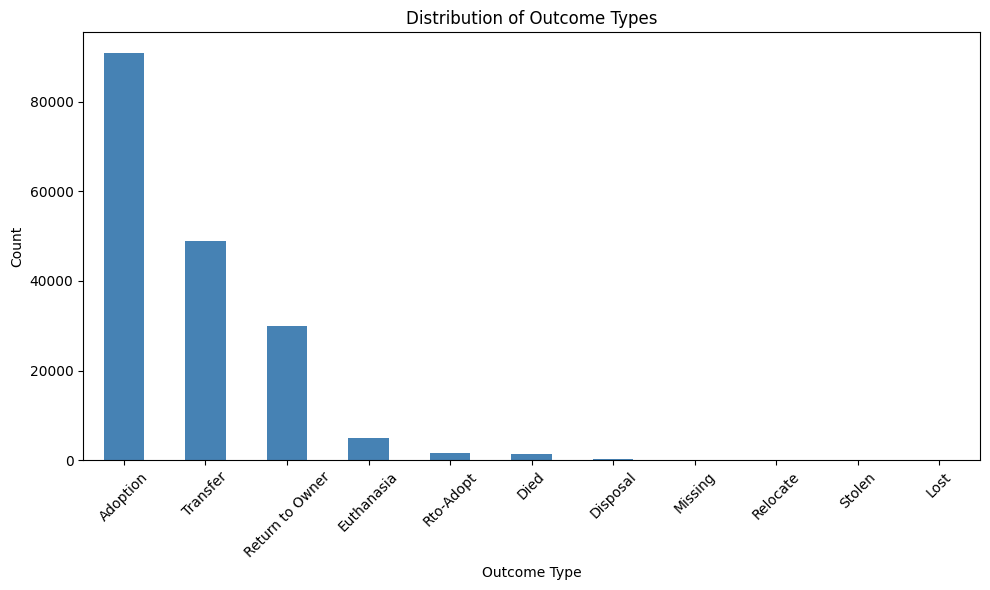

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

#outcome type distribution figure
plt.figure(figsize=(10, 6))
df['Outcome Type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Outcome Types')
plt.xlabel('Outcome Type')  
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [98]:
#consolidate outcome types into fourmain categories 
outcome_mapping = {
    'Adoption' : 'Adopted',
    'Rto-Adopt' : 'Adopted', 
    'Transfer' : 'Transferred', 
    'Relocate' : 'Transferred',
    'Return to Owner' : 'Returned to Owner',
    'Euthanasia' : 'Other'
    'Died': 'Other',
    'Disposal' : 'Other',
    'Missing' : 'Other', 
    'Stolen' : 'Other',
    'Lost' : 'Other', 
}

df['Outcome Category'] = df['Outcome Type'].map(outcome_mapping)

print("Outcome Category Distribution:")
print(df['Outcome Category'].value_counts())

#plot the new outcome category distribution
plt.figure(figsize=(8, 5))
df['Outcome Category'].value_counts().plot(kind='bar', color='coral')
plt.title('Consolidated Outcome Category Distribution')
plt.xlabel('Outcome Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
           

SyntaxError: invalid syntax (1150686132.py, line 9)